In [1]:
# 데이터 처리 및 분석
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import warnings

# 경로 설정
import os
import sys

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 출력 설정
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# 한글 폰트 설정
import platform

if platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif platform.system() == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
else:
    plt.rcParams["font.family"] = "NanumGothic"

plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.figsize"] = (12, 6)

# 시드 설정
np.random.seed(42)

print("-" * 60)
print("라이브러리 로드 완료")
print("한글 폰트 설정 완료!")
print("-" * 60)

------------------------------------------------------------
라이브러리 로드 완료
한글 폰트 설정 완료!
------------------------------------------------------------


In [6]:
os.getcwd()

'd:\\Dev\\airbnb_price_prediction'

In [ ]:
# 현재 작업 디렉토리(notebooks)의 부모 디렉토리(root)를 경로에 추가
os.chdir(os.path.abspath(".."))
print(os.getcwd())

df = pd.read_csv("data/2025_Airbnb_NYC_listings.csv").drop(columns="Unnamed: 0")
df.head()

d:\Dev\airbnb_price_prediction


,id,source,name,description,neighborhood_overview,host_id,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,calendar_updated,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,36121,city scrape,Lg Rm in Historic Prospect Heights,Cozy space share in the heart of a great neigh...,Full of tree-lined streets and beautiful brown...,62165,Michael,2009-12-11,"New York, NY",I’m an urban planner working for an internatio...,NaN,NaN,NaN,f,Prospect Heights,1.0,3.0,"['email', 'phone', 'work_email']",t,t,Neighborhood highlights,Prospect Heights,Brooklyn,40.673760,-73.966110,Private room in rental unit,Private room,1,1.0,1 shared bath,1.0,1.0,"[""Refrigerator"", ""Dishes and silverware"", ""Wif...",$200.00,90,365,90.0,90.0,365.0,365.0,90.0,365.0,NaN,t,27,57,87,362,2025-03-03,9,0,0,301,0,0,0.0,2010-12-11,2013-05-10,4.88,5.00,4.80,5.00,5.00,5.00,5.00,NaN,f,1,0,1,0,0.05
1,36647,city scrape,"1 Bedroom & your own Bathroom, Elevator Apartment",Private bedroom with your own bathroom in a 2 ...,"Manhattan, SE corner of 2nd Ave/ E. 110th street",157798,Irene,2010-07-04,"New York, NY",NaN,NaN,NaN,100%,f,East Harlem,1.0,1.0,"['email', 'phone']",t,t,Neighborhood highlights,East Harlem,Manhattan,40.792454,-73.940742,Private room in condo,Private room,2,1.0,1 private bath,1.0,1.0,"[""Oven"", ""Blender"", ""Luggage dropoff allowed"",...",$82.00,30,999,30.0,30.0,999.0,999.0,30.0,999.0,NaN,t,0,0,0,204,2025-03-03,102,0,0,143,0,0,0.0,2010-10-04,2023-12-09,4.77,4.82,4.76,4.88,4.90,4.38,4.71,NaN,f,1,0,1,0,0.58
2,38663,city scrape,Luxury Brownstone in Boerum Hill,"Beautiful, large home in great hipster neighbo...","diverse, lively, hip, cool: loaded with restau...",165789,Sarah,2010-07-13,"New York, NY",I am a lawyer and work as an executive at an a...,within a few hours,100%,40%,f,Boerum Hill,1.0,3.0,"['email', 'phone', 'work_email']",t,t,Neighborhood highlights,Boerum Hill,Brooklyn,40.684420,-73.980680,Private room in home,Private room,2,2.5,2.5 baths,5.0,5.0,"[""Portable fans"", ""Oven"", ""Baking sheet"", ""Fir...",$765.00,3,60,3.0,3.0,60.0,60.0,3.0,60.0,NaN,t,30,49,66,326,2025-03-02,43,0,0,267,0,0,0.0,2012-07-09,2023-08-30,4.70,4.83,4.52,4.88,4.88,4.86,4.62,OSE-STRREG-0001784,f,1,0,1,0,0.28
3,38833,city scrape,Spectacular West Harlem Garden Apt,This is a very large and unique space. An inc...,West Harlem is now packed with great restauran...,166532,Matthew,2010-07-14,"New York, NY",I have been a New Yorker for a long time\n and...,within an hour,100%,97%,t,Harlem,1.0,1.0,"['email', 'phone']",t,t,Neighborhood highlights,Harlem,Manhattan,40.818058,-73.946671,Entire home,Entire home/apt,2,1.0,1 bath,1.0,1.0,"[""Fire extinguisher"", ""Clothing storage: close...",$139.00,2,45,2.0,2.0,1125.0,1125.0,2.0,1125.0,NaN,t,7,18,25,25,2025-03-03,241,42,3,25,43,255,35445.0,2010-08-28,2025-02-21,4.85,4.87,4.50,4.96,4.96,4.79,4.82,OSE-STRREG-0000476,

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 22308 entries, 0 to 22307
Data columns (total 72 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            22308 non-null  int64  
 1   source                                        22308 non-null  str    
 2   name                                          22308 non-null  str    
 3   description                                   21903 non-null  str    
 4   neighborhood_overview                         12262 non-null  str    
 5   host_id                                       22308 non-null  int64  
 6   host_name                                     22288 non-null  str    
 7   host_since                                    22288 non-null  str    
 8   host_location                                 17025 non-null  str    
 9   host_about                                    13391 non-null  str    
 1

In [5]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,22308.0,NaN,NaN,NaN,594931827143523456.0,516864910912614336.0,6848.0,41372693.25,727563706116818176.0,1067266443718449536.0,1366912874990325504.0
source,22308,1,city scrape,22308,NaN,NaN,NaN,NaN,NaN,NaN,NaN
name,22308,21342,Wyndham Midtown 45 Resort | King Bed Hotel Room,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN
description,21903,17854,Keep it simple at this peaceful and centrally-...,72,NaN,NaN,NaN,NaN,NaN,NaN,NaN
neighborhood_overview,12262,8232,This furnished property is located on the Uppe...,106,NaN,NaN,NaN,NaN,NaN,NaN,NaN
host_id,22308.0,NaN,NaN,NaN,216347621.868881,202510512.17774,1678.0,27181542.0,137358866.0,415840703.0,681436540.0
host_name,22288,5343,Blueground,1094,NaN,NaN,NaN,NaN,NaN,NaN,NaN
host_since,22288,4567,2016-12-16,1096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
host_location,17025,421,"New York, NY",13441,NaN,NaN,NaN,NaN,NaN,NaN,NaN
host_about,13391,5804,"We’re Blueground, a global proptech company wi...",1094,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
df_cleaned = pd.read_csv("data/df_cleaned.csv")

In [8]:
df_cleaned.shape

(22308, 73)

Successfully saved: docs/images/가격 히스토그램.png


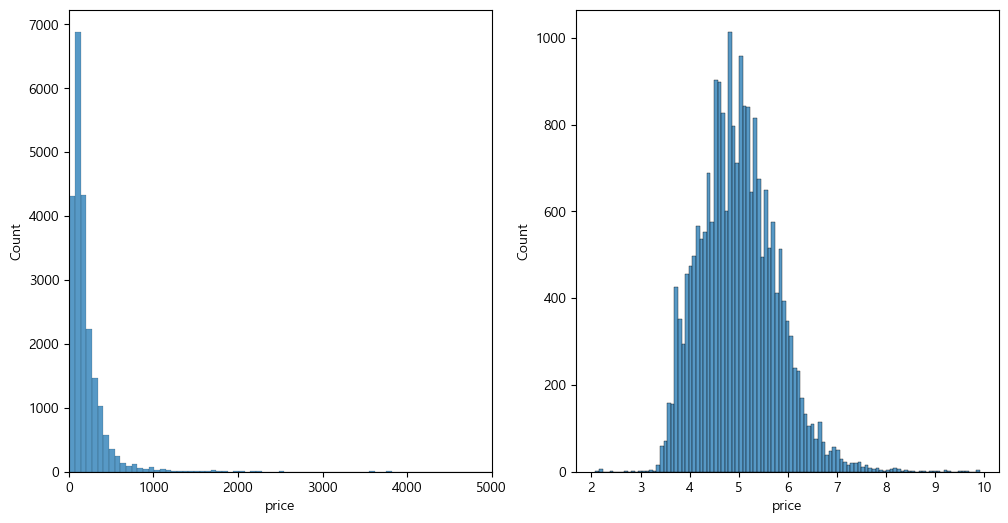

In [9]:
from src import utils

fig, axs = plt.subplots(1, 2)

sns.histplot(df_cleaned["price"], ax=axs[0])
axs[0].set_xlim(0, 5000)

log_price = np.log(df_cleaned["price"] + 1)
sns.histplot(log_price, ax=axs[1])

utils.save_image(fig, "가격 히스토그램")

정규성 검정 결과: 2.1864019793152053e-46


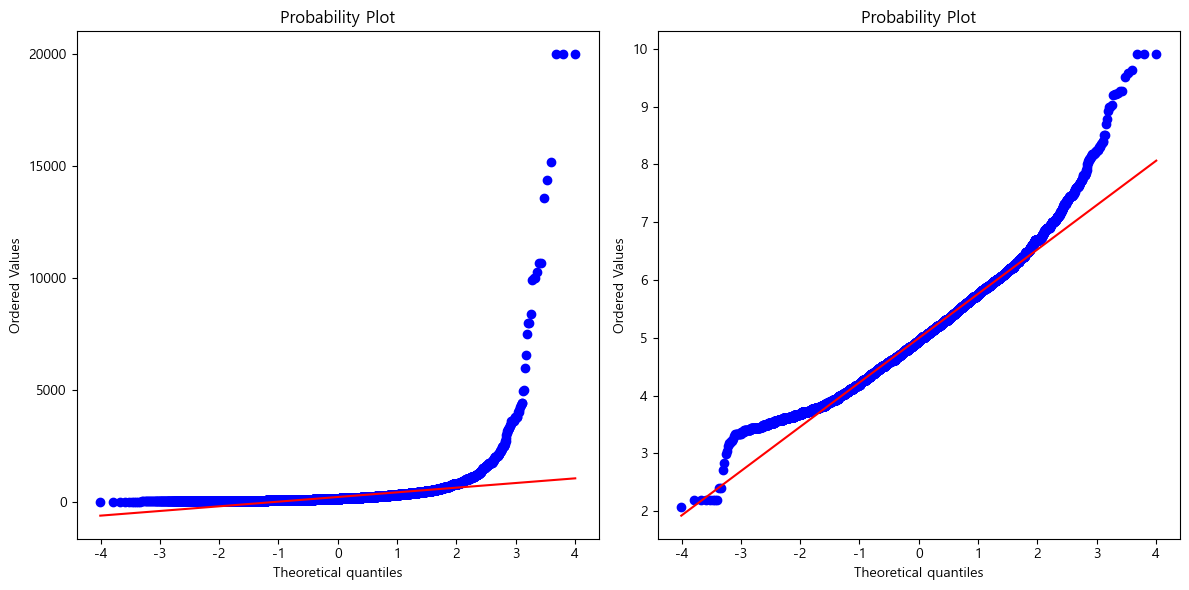

Successfully saved: docs/images/가격 QQ plot.png
왜도 :  0.5681430454641385
첨도 :  1.0437562006959409


In [10]:
from scipy.stats import shapiro, probplot

shapiro_stat, p_val = shapiro(log_price)
print("정규성 검정 결과:", p_val)

fig, axs = plt.subplots(1, 2)

probplot(df_cleaned["price"], dist="norm", plot=axs[0])
probplot(log_price, dist="norm", plot=axs[1])
plt.tight_layout()
plt.show()

utils.save_image(fig, "가격 QQ plot")

print("왜도 : ", log_price.skew())
print("첨도 : ", log_price.kurt())

# PJH

In [73]:
# 총 리뷰 수
df_cleaned[["number_of_reviews"]]

,number_of_reviews
0,9
1,102
2,43
3,241
4,274
...,...
22303,0
22304,0
22305,0
22306,0


In [ ]:
# 데이터 타입
df_cleaned["number_of_reviews"].dtypes

dtype('int64')

In [ ]:
# 대표지표 살펴보기 : 평균, 최소/최대값, 중간값, 상/하위 25% 값
df_cleaned[["number_of_reviews"]].describe().round(2)

,number_of_reviews
count,22308.00
mean,34.35
std,76.78
min,0.00
25%,0.00
50%,5.00
75%,35.00
max,2749.00


In [ ]:
# 결측치 확인
df_cleaned["number_of_reviews"].isna().sum()

np.int64(0)

In [ ]:
# 총 리뷰수 중 0의 비율 -> 30% 이상
zero_ratio = (df_cleaned["number_of_reviews"] == 0).sum() / len(df_cleaned) * 100

print(f"리뷰 0개 비율: {zero_ratio:.1f}%")
print(f"리뷰 0개 숙소: {len(df_cleaned[df_cleaned["number_of_reviews"] == 0])}개")
print(f"전체 숙소: {len(df_cleaned)}개")

리뷰 0개 비율: 30.5%
리뷰 0개 숙소: 6798개
전체 숙소: 22308개


리뷰 수 0의 개수가 전체의 30%이상이라, 대푯값 왜곡
- 평균 리뷰 수 34 뭔데? 신뢰성 없음
- 중앙값 5개 ㅋ
- 25% 까지도 0개, 75% 35개 == 리뷰 수가 많은 순으로 숙소 보기
- 최댓값 2749 심상찮음. : 거의 도시의 랜드마크급 숙소?

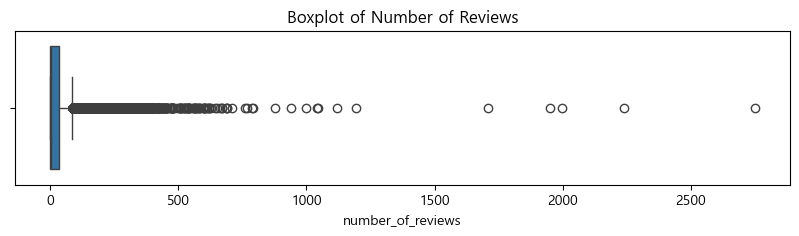

In [17]:
# 이상치 확인
plt.figure(figsize=(10, 2))
sns.boxplot(x=df_cleaned["number_of_reviews"])
plt.title("Boxplot of Number of Reviews")
plt.show()

In [83]:
df_cleaned[(df_cleaned["number_of_reviews"] > 800) & (df_cleaned["number_of_reviews"] < 3000)][["number_of_reviews"]]

,number_of_reviews
3241,1046
4979,1193
4986,1951
7870,1998
7903,1043
8122,876
8301,1120
9458,2238
9499,939
10703,1709


- 리뷰 수 800 이상 부터 띄엄띄엄
### 이산형 범주화
- 리뷰 유무?
- super_host(>=500)/activate(35~500)/biginning(1~34)/non_activate(0)
- 1000이상을 1000으로 처리할지


In [13]:
# 필터링
review_filtered_1 = df_cleaned[(df_cleaned["number_of_reviews"] > 0) & (df_cleaned["number_of_reviews"] < 35)].copy()

print(f"리뷰 수 0초과 35미만 행 개수: {len(review_filtered_1)}개")
review_filtered_1[["number_of_reviews"]].describe().round(2)

리뷰 수 0초과 35미만 행 개수: 9848개


,number_of_reviews
count,9848.00
mean,10.09
std,9.41
min,1.00
25%,2.00
50%,7.00
75%,16.00
max,34.00


In [ ]:
review_filtered_2 = df_cleaned[(df_cleaned["number_of_reviews"] >= 35) & (df_cleaned["number_of_reviews"] < 50)].copy()

print(f"리뷰 수 35이상 50미만 행 개수: {len(review_filtered_1)}개")

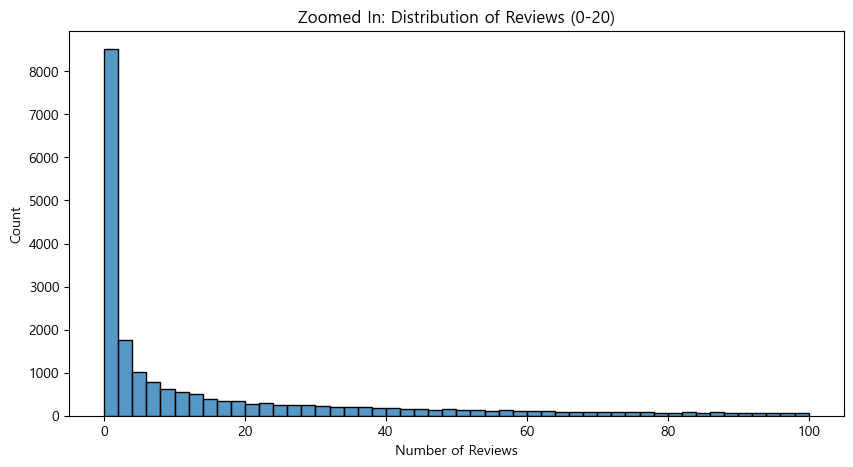

In [ ]:
plt.figure(figsize=(10, 5))

sns.histplot(df_cleaned["number_of_reviews"], binrange=(0, 100), bins=50)
plt.title("Zoomed In: Distribution of Reviews (0-20)")
plt.xlabel("Number of Reviews")
plt.ylabel("Count")
plt.show()

In [20]:
# 0보다 큰 리뷰만
review_nonzero = df_cleaned[df_cleaned["number_of_reviews"] > 0]
(review_nonzero["number_of_reviews"] > 0).sum()

np.int64(15510)

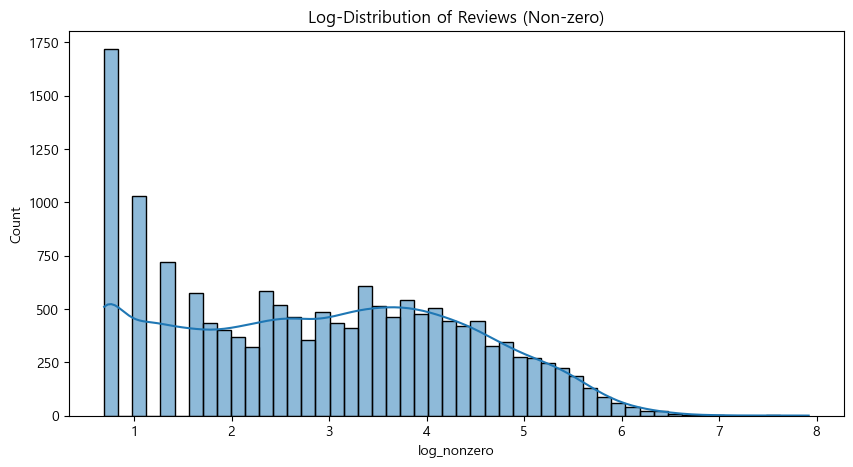

In [ ]:
# 로그 변환
review_nonzero = df_cleaned[df_cleaned["number_of_reviews"] > 0].copy()
review_nonzero["log_nonzero"] = np.log1p(review_nonzero["number_of_reviews"])

plt.figure(figsize=(10, 5))
sns.histplot(review_nonzero["log_nonzero"], bins=50, kde=True)
plt.title("Log-Distribution of Reviews (Non-zero)")
plt.show()

### 4개부터 우하향

In [22]:
q3 = df_cleaned["number_of_reviews"].quantile(0.75)

top_25_df_cleaned = df_cleaned[df_cleaned["number_of_reviews"] >= q3].copy()

print(f"상위 25% 리뷰 수: {q3}개")
print(f"데이터 개수: {len(top_25_df_cleaned)}개")
print(top_25_df_cleaned["number_of_reviews"].describe())

상위 25% 리뷰 수: 35.0개
데이터 개수: 5662개
count    5662.000000
mean      117.794772
std       116.932080
min        35.000000
25%        52.000000
50%        81.000000
75%       144.000000
max      2749.000000
Name: number_of_reviews, dtype: float64


In [ ]:
# 한번에 상관계수 확인
review_related_cols = [
    "host_response_rate",
    "host_acceptance_rate",
    "price",
    "accommodates",
    "availability_30",
    "estimated_occupancy_l365d",
    "review_scores_cleanliness",
    "review_scores_location",
    "review_scores_value",
    "review_scores_accuracy",
    "review_scores_communication",
]

df_cleaned[review_related_cols + ["number_of_reviews", "review_scores_rating"]].corr()[
    ["number_of_reviews", "review_scores_rating"]
].sort_values("review_scores_rating", ascending=False)

,number_of_reviews,review_scores_rating
review_scores_rating,0.066157,1.000000
review_scores_accuracy,0.085623,0.852456
review_scores_value,0.113258,0.846790
review_scores_communication,0.077162,0.787424
review_scores_cleanliness,0.088116,0.785250
review_scores_location,0.036335,0.605592
estimated_occupancy_l365d,0.365630,0.110858
host_response_rate,0.062908,0.069113
number_of_reviews,1.000000,0.066157
price,-0.051742,0.043957


In [ ]:
# 리뷰 많은 순으로 데이터 정렬해서 패턴 찾아보기
cols = [
    "name",
    "host_name",
    "number_of_reviews",
    "price",
    "review_scores_rating",
    "host_is_superhost",
    "neighbourhood",
    "room_type",
]

df_cleaned[cols].sort_values("number_of_reviews", ascending=False).head(20)

,name,host_name,number_of_reviews,price,review_scores_rating,host_is_superhost,neighbourhood,room_type
13316,"Safe and Cozy Hostel Room, 1 person, Manhattan",Alfred,2749,58.0,4.70,False,NaN,Private room
9458,Individual Cubicle Room in NYC/Mixed Floor,Alex And Zeena,2238,65.0,4.58,False,Neighborhood highlights,Private room
7870,Untitled at 3 Freeman - Studio Queen,Untitled,1998,159.0,4.88,True,NaN,Entire home/apt
4986,Amazing Micro Unit W/ communal rooftop and kit...,The Ridge,1951,162.0,4.54,False,Neighborhood highlights,Private room
10703,SoHo View Room (Full-Size Bed) in Hotel Comfort,SoHoBlu,1709,124.0,4.53,False,Neighborhood highlights,Entire home/apt
4979,Beautiful Standard Full Room at The Ridge,The Ridge,1193,172.0,4.42,False,Neighborhood highlights,Private room
8301,Untitled at 3 Freeman - Studio Mini,Untitled,1120,152.0,4.89,True,NaN,Entire home/apt
3241,Freehand New York - Premium Queen Room,Freehand,1046,256.0,4.48,False,NaN,Hotel room
7903,Untitled 3 Freeman - Studio Queen City View,Untitled,1043,179.0,4.87,True,NaN,Entire home/apt
10773,"SoHo ""Room Selected at Check-in"" in Hotel Comfort",SoHoBlu,999,103.0,4.49,False,Neighborhood highlights,Entire home/apt


In [44]:
# 평점이 높은 순으로 정렬해서 패턴 파악해보기
cols = [
    "name",
    "host_name",
    "number_of_reviews",
    "price",
    "review_scores_rating",
    "host_is_superhost",
    "neighbourhood",
    "room_type",
]

df_cleaned[cols].sort_values("review_scores_rating", ascending=False).head(30)

,name,host_name,number_of_reviews,price,review_scores_rating,host_is_superhost,neighbourhood,room_type
21699,NYC Skyline Penthouse 2Br/2Bath,Andrew,2,942.0,5.0,False,NaN,Entire home/apt
21697,Upscale Comfort: Stylish 2BR in the Heart of NYC,Krystian,2,344.0,5.0,True,Neighborhood highlights,Entire home/apt
21674,Spacious 3BR Family Haven in Lower Manhattan,Rouzbeh,2,465.0,5.0,False,Neighborhood highlights,Entire home/apt
21339,Modern Two Bedroom in NYC!,Frank,4,241.0,5.0,False,NaN,Entire home/apt
21228,Private Room Home Cinema Queens,Wayne,5,100.0,5.0,False,NaN,Private room
21173,NYC Spacious 3BR • LGA/ JFK • 15 Mins To City,Sumaiya,1,299.0,5.0,False,NaN,Entire home/apt
21111,Exquisite Studio Near JFK,Abideen,1,86.0,5.0,False,NaN,Private room
21069,Heaven Short World - Garden Room,Haim Shlomo,1,45.0,5.0,False,NaN,Private room
21029,Cozy Townhouse In The Bronx. 3,Itohan,1,41.0,5.0,False,NaN,Private room
21027,Cozy Townhouse In The Bronx. 2,Itohan,1,50.0,5.0,False,NaN,Private room


In [ ]:
# 평점 4.0 이상인데 슈퍼호스트가 아닌 숙소
high_rating_not_super = df_cleaned[
    (df_cleaned["review_scores_rating"] >= 4.0) & (df_cleaned["host_is_superhost"] == False)
]

# 평점 4.0 이상일 때
high_rating = df_cleaned[df_cleaned["review_scores_rating"] >= 4.0]

ratio = len(high_rating_not_super) / len(high_rating) * 100

print(f"평점 4.0 이상 전체: {len(high_rating)}개")
print(f"그 중 슈퍼호스트 X: {len(high_rating_not_super)}개")
print(f"비율: {ratio:.1f}%")

평점 4.0 이상 전체: 15029개
그 중 슈퍼호스트 X: 9352개
비율: 62.2%


In [ ]:
# 리뷰 수 상위 5% 기준
q95 = df_cleaned["number_of_reviews"].quantile(0.95)

# 리뷰 많은데 슈퍼호스트 아닌 숙소
many_reviews_not_super = df_cleaned[
    (df_cleaned["number_of_reviews"] >= q95) & (df_cleaned["host_is_superhost"] == False)
]

# 리뷰 많은 숙소 전체
many_reviews = df_cleaned[df_cleaned["number_of_reviews"] >= q95]

ratio = len(many_reviews_not_super) / len(many_reviews) * 100

print(f"리뷰 상위 5% 기준: {q95:.0f}개 이상")
print(f"리뷰 많은 숙소 전체: {len(many_reviews)}개")
print(f"그 중 슈퍼호스트 X: {len(many_reviews_not_super)}개")
print(f"비율: {ratio:.1f}%")

리뷰 상위 5% 기준: 170개 이상
리뷰 많은 숙소 전체: 1117개
그 중 슈퍼호스트 X: 556개
비율: 49.8%


In [71]:
# 평점 4.8 이상 숙소 중 room_type 빈도
high_rating = df_cleaned[df_cleaned["review_scores_rating"] >= 4.8]

high_rating["room_type"].value_counts()

room_type
Entire home/apt    5359
Private room       3684
Hotel room           48
Shared room          39
Name: count, dtype: int64

In [45]:
# 상관계수
corr = df_cleaned["number_of_reviews"].corr(df_cleaned["review_scores_rating"])
print(f"리뷰 수 vs 평점 상관계수: {corr:.3f}")

리뷰 수 vs 평점 상관계수: 0.066


In [ ]:
# 리뷰, 평점 있는 숙소만
nrsr_filtered = df_cleaned[(df_cleaned["number_of_reviews"] > 0) & (df_cleaned["review_scores_rating"] > 0)]

corr2 = nrsr_filtered["number_of_reviews"].corr(nrsr_filtered["review_scores_rating"])
print(f"리뷰 있는 숙소만 상관계수: {corr2:.3f}")

리뷰 있는 숙소만 상관계수: 0.066


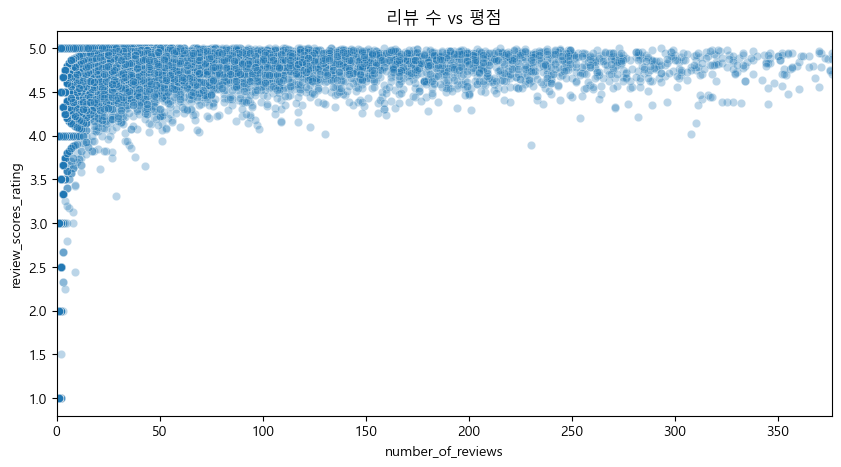

In [62]:
# 산점도
plt.figure(figsize=(10, 5))
sns.scatterplot(data=nrsr_filtered, x="number_of_reviews", y="review_scores_rating", alpha=0.3)
plt.xlim(0, nrsr_filtered["number_of_reviews"].quantile(0.99))
plt.title("리뷰 수 vs 평점")
plt.show()

In [ ]:
# 리뷰 구간별 평균 평점
bins = [0, 10, 50, 100, 300, 3000]
labels = ["~10개", "10~50개", "50~100개", "100~300개", "300개+"]

nrsr_filtered["review_group"] = pd.cut(nrsr_filtered["number_of_reviews"], bins=bins, labels=labels)

nrsr_filtered.groupby("review_group")["review_scores_rating"].agg(
    숙소수="count", 평균평점="mean", 중앙값="median"
).round(3)

,숙소수,평균평점,중앙값
review_group,,,
~10개,6156,4.651,5.000
10~50개,5023,4.757,4.810
50~100개,2101,4.790,4.830
100~300개,1936,4.795,4.830
300개+,294,4.769,4.815


In [ ]:
# 극히 드문 경우 --> 리뷰 많은데 평점 낮은 숙소
weird = df_cleaned[(df_cleaned["number_of_reviews"] >= 100) & (df_cleaned["review_scores_rating"] < 4.0)]
print(f"리뷰 100개 이상, 평점 4.0 미만: {len(weird)}개")
weird[["name", "number_of_reviews", "review_scores_rating", "price"]].sort_values(
    "number_of_reviews", ascending=False
).head(10)

리뷰 100개 이상, 평점 4.0 미만: 1개


,name,number_of_reviews,review_scores_rating,price
18020,Cozy Queen Room in Times Square,230,3.89,93.0


# 리뷰 수와 가격 간 상관 관계

In [41]:
corr = df_cleaned["number_of_reviews"].corr(df_cleaned["price"])
print(f"리뷰 수 vs 가격 상관계수: {corr:.3f}")

리뷰 수 vs 가격 상관계수: -0.052


In [33]:
corr = df_cleaned["review_scores_rating"].corr(df_cleaned["price"])
print(f"평점 vs 가격 상관계수: {corr:.3f}")

평점 vs 가격 상관계수: 0.044


- 0.0 ~ 0.2 : 거의 없음 
- 0.4 ~ 0.6 : 중간 상관
- 0.6 ~ 1.0 : 강한 상관

### 상관계수 해석
- -0.052 : 리뷰 많다고 싸지 않고
- 0.044 : 평점 높다고 비싸지 않다

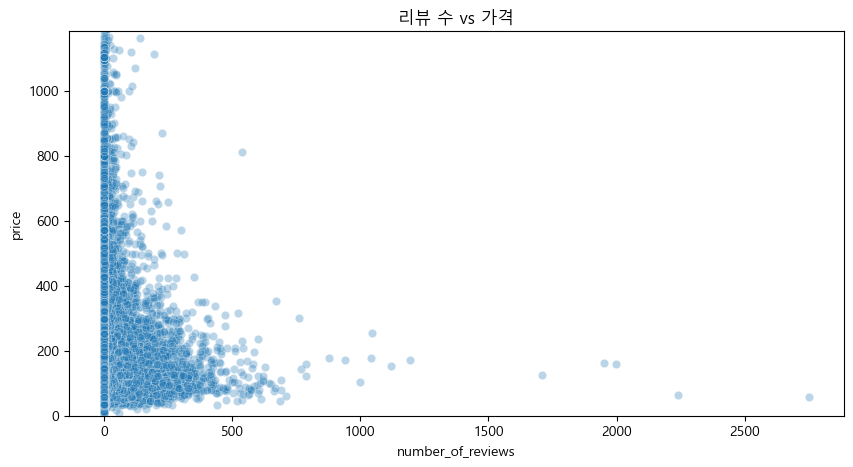

In [ ]:
# 리뷰 수 vs 가격 산점도 시각화
plt.figure(figsize=(10, 5))

sns.scatterplot(data=df_cleaned, x="number_of_reviews", y="price", alpha=0.3)
plt.ylim(0, df_cleaned["price"].quantile(0.99))
plt.title("리뷰 수 vs 가격")
plt.show()

리뷰 0~100개 구간: 대부분의 숙소 밀집
리뷰 500개 이상: 소수의 가격이 낮은 숙소들

1. 리뷰 많을수록 가격이 낮다
리뷰 수 많은 숙소 → 대부분 $200 이하
- 저가 숙소 : 예약이 많아 리뷰가 쌓임
- 고가 숙소 : 예약 빈도 낮음 = 리뷰 적음

2. 고가 숙소는 리뷰가 거의 없음
- $800 이상 숙소 → 리뷰 100개 미만에 집중
- 비쌀수록 예약 선택받기 어려움

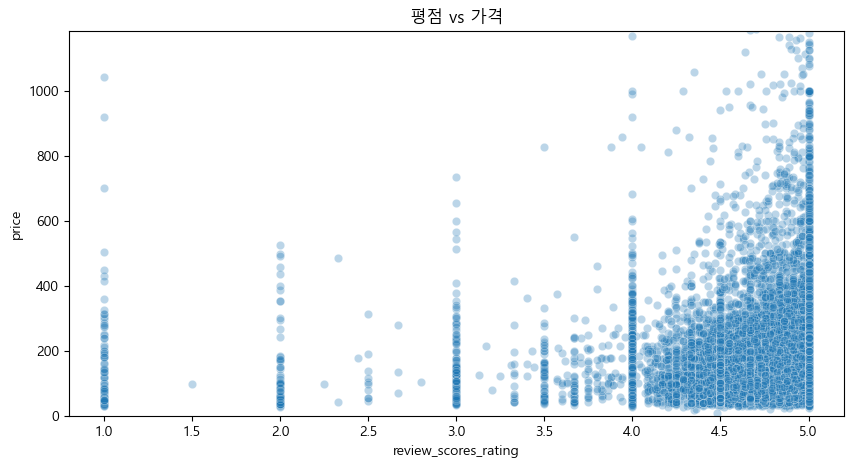

In [38]:
# 평점 vs 가격 산점도 시각화
plt.figure(figsize=(10, 5))

sns.scatterplot(data=df_cleaned, x="review_scores_rating", y="price", alpha=0.3)
plt.ylim(0, df_cleaned["price"].quantile(0.99))
plt.title("평점 vs 가격")
plt.show()

-------------------------------------------
# reviews_per_month 월별 평균 리뷰 수

In [27]:
df_cleaned[["reviews_per_month"]]

,reviews_per_month
0,0.05
1,0.58
2,0.28
3,1.36
4,1.54
...,...
22303,NaN
22304,NaN
22305,NaN
22306,NaN


In [28]:
df_cleaned[["reviews_per_month"]].describe().round(4)

,reviews_per_month
count,15510.0000
mean,1.1600
std,2.2238
min,0.0100
25%,0.1800
50%,0.5000
75%,1.4900
max,117.9800


In [29]:
# 전체 15510개 중 결측치 6798개
df_cleaned["reviews_per_month"].isna().sum()

np.int64(6798)

1. 평균(1.16) 중앙값(0.5) : 평균을 끌어올리는 데이터가 있다.
2. 최솟값 0.01 최댓값 117.98 : 이상치 확인할 것 
3. 결측치 의미: 리뷰가 하나도 없는 숙소

In [30]:
# 결측치 -> 리뷰수 0으로
df_cleaned["reviews_per_month"] = df_cleaned["reviews_per_month"].fillna(0)

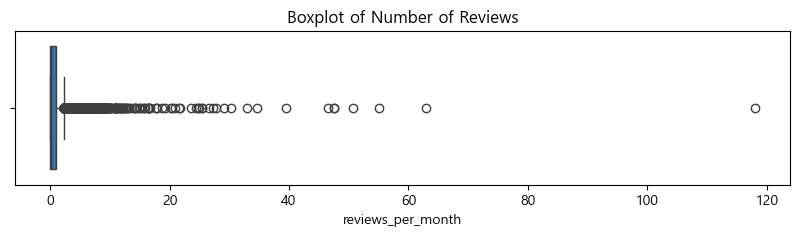

In [31]:
# 이상치 확인
plt.figure(figsize=(10, 2))
sns.boxplot(x=df_cleaned["reviews_per_month"])
plt.title("Boxplot of Number of Reviews")
plt.show()

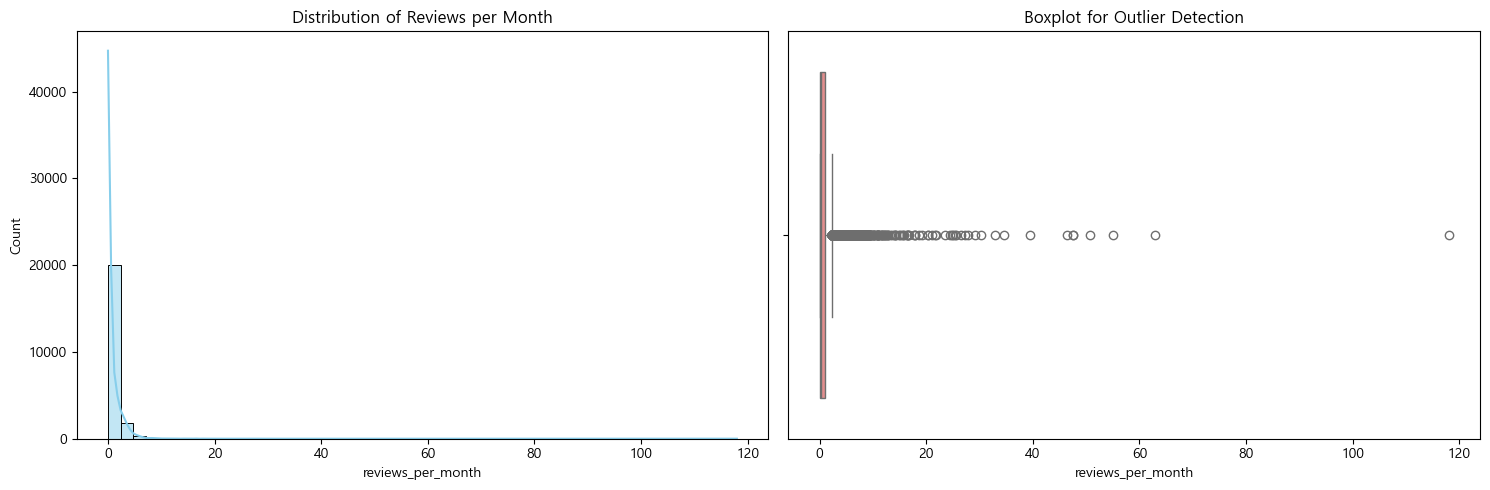

In [32]:
plt.figure(figsize=(15, 5))

# 1. 히스토그램 (치우침 확인)
plt.subplot(1, 2, 1)
sns.histplot(df_cleaned["reviews_per_month"], bins=50, kde=True, color="skyblue")
plt.title("Distribution of Reviews per Month")

# 2. 박스플롯 (이상치 시각화)
plt.subplot(1, 2, 2)
sns.boxplot(x=df_cleaned["reviews_per_month"], color="lightcoral")
plt.title("Boxplot for Outlier Detection")

plt.tight_layout()
plt.show()

# review_scores_rating 전반적인 평점

In [33]:
# 연속형
df_cleaned[["review_scores_rating"]]

,review_scores_rating
0,4.88
1,4.77
2,4.70
3,4.85
4,4.82
...,...
22303,NaN
22304,NaN
22305,NaN
22306,NaN


In [34]:
df_cleaned[["review_scores_rating"]].isna().sum()

review_scores_rating    6798
dtype: int64

In [35]:
# 결측치 -> 리뷰 수 0
df_cleaned["review_scores_rating"] = df_cleaned["review_scores_rating"].fillna(0)

In [36]:
# 평점 이상치 확인
df_cleaned[["review_scores_rating"]].describe().round(3)

,review_scores_rating
count,22308.000
mean,3.285
std,2.208
min,0.000
25%,0.000
50%,4.690
75%,4.920
max,5.000


- 전체의 25% 이상이 평점 0, 중앙값 갑자기 4.69 (평점이 0 아니면 4점대 이상) → 중간값이 거의 없음. 즉, 평가받은 숙소는 대부분 고평점 인 것(리뷰를 썼다는 사실 = 만족도 높음)
- 최솟값 0, 최댓값 5 : 최고점이 5점

#### 평점 0 처리 방법 선택
- 분석에서 제외: df_cleaned[df_cleaned['review_scores_rating'] > 0]
- 리뷰 수도 0이므로 사실상 제외해도됨

In [37]:
# 실제 평가받은 숙소만 보기
rated = df_cleaned[df_cleaned["review_scores_rating"] > 0]
rated[["review_scores_rating"]].describe().round(3)

,review_scores_rating
count,15510.000
mean,4.724
std,0.457
min,1.000
25%,4.662
50%,4.850
75%,5.000
max,5.000


# review_scores_cleanliness 청결도 평점

In [38]:
df_cleaned[["review_scores_cleanliness"]].isna().sum()

review_scores_cleanliness    6798
dtype: int64

In [39]:
df_cleaned["review_scores_cleanliness"] = df_cleaned["review_scores_cleanliness"].fillna(0)

In [40]:
df_cleaned[["review_scores_cleanliness"]].describe().round(2)

,review_scores_cleanliness
count,22308.00
mean,3.26
std,2.19
min,0.00
25%,0.00
50%,4.64
75%,4.91
max,5.00


In [41]:
rated_clean = df_cleaned[df_cleaned["review_scores_rating"] > 0]
rated_clean[["review_scores_rating"]].describe().round(3)

,review_scores_rating
count,15510.000
mean,4.724
std,0.457
min,1.000
25%,4.662
50%,4.850
75%,5.000
max,5.000


In [42]:
# 구간별 비율 확인
bins = [0, 3.0, 4.0, 4.5, 4.8, 5.0]
labels = ["~3점", "3~4점", "4~4.5점", "4.5~4.8점", "4.8~5점"]

rated_clean = df_cleaned[df_cleaned["review_scores_cleanliness"] > 0].copy()
rated_clean["rating_clean_group"] = pd.cut(rated["review_scores_cleanliness"], bins=bins, labels=labels)

print((rated_clean["rating_clean_group"].value_counts(normalize=True).round(3) * 100).round(1).astype(int))

rating_clean_group
4.8~5점      52
4.5~4.8점    27
4~4.5점      13
3~4점         5
~3점          1
Name: proportion, dtype: int64


### 4.8 이상/미만으로 분류?
- 대부분의 숙소가 4.5 ~ 5.0 사이에 몰려있음
- 평점이 대부분 높으므로 이걸 가지고 숙소의 차등을 매기기가 어려움

# review_scores_communication 커뮤니케이션 평점

In [43]:
df_cleaned["review_scores_communication"] = df_cleaned["review_scores_communication"].fillna(0)

In [44]:
df_cleaned["review_scores_communication"].isna().sum()

np.int64(0)

In [45]:
df_cleaned[["review_scores_communication"]].describe().round(2)

,review_scores_communication
count,22308.00
mean,3.35
std,2.24
min,0.00
25%,0.00
50%,4.83
75%,5.00
max,5.00


In [46]:
rated_comm = df_cleaned[df_cleaned["review_scores_communication"] > 0]
rated_comm[["review_scores_communication"]].describe().round(3)

,review_scores_communication
count,15510.000
mean,4.813
std,0.420
min,1.000
25%,4.800
50%,4.940
75%,5.000
max,5.000


 - 전체 평점 평균보다 소통 평점 평균이 더 높음
 - 호스트들이 소통을 신경쓰고 있음을 알 수 있다?
 - 25%~75% 가 고작 0.1차이, 대부분 만점에 가깝기 때문에 여전히 좋은 숙소와 안좋은 숙소를 구별하기 어려움
 - 소통 평점이 하위 25% 이하일 경우 숙소에 문제가 있었음을 알 수 있나?

In [ ]:
# 소통 불량 숙소 확인
low_comm = df_cleaned[
    (df_cleaned["review_scores_communication"] >= 2.0) & (df_cleaned["review_scores_communication"] >= 1.0)
]
print(f"소통 평점 1.0 이상 2.0 미만: {len(low_comm)}개")
print(f"비율: {len(low_comm)/len(df_cleaned)*100:.1f}%")

소통 평점 1.0 이상 2.0 미만: 15429개
비율: 69.2%


In [ ]:
low_comm = df_cleaned[
    (df_cleaned["review_scores_communication"] <= 1.0) & (df_cleaned["review_scores_communication"] > 0)
]
print(f"소통 평점 0 초과 1.0 미만: {len(low_comm)}개")
print(f"비율: {len(low_comm)/len(df_cleaned)*100:.1f}%")

소통 평점 0 초과 1.0 미만: 81개
비율: 0.4%


In [ ]:
# 리뷰는 있는데 평점은 없는 것
review_n_rating = df_cleaned[(df_cleaned["number_of_reviews"] > 0) & (df_cleaned["review_scores_rating"] == 0)]

# 리뷰도 있고 평점도 있는 것
review_y_rating = df_cleaned[(df_cleaned["number_of_reviews"] > 0) & (df_cleaned["review_scores_rating"] > 0)]

# 리뷰는 없는데 평점은 있는 것
n_review_y_rating = df_cleaned[(df_cleaned["number_of_reviews"] == 0) & (df_cleaned["review_scores_rating"] > 0)]

print(f"리뷰 O / 평점 X: {len(review_n_rating)}개")
print(f"리뷰 O / 평점 O: {len(review_y_rating)}개")
print(f"리뷰 X / 평점 O: {len(n_review_y_rating)}개")

리뷰 O / 평점 X: 0개
리뷰 O / 평점 O: 15510개
리뷰 X / 평점 O: 0개


In [ ]:
# 슈퍼호스트일 떄 리뷰 수
superhost = df_cleaned[df_cleaned["host_is_superhost"] == True]

print(f"슈퍼호스트 수: {len(superhost)}개")
print(superhost["number_of_reviews"].describe().round(2))

슈퍼호스트 수: 6135개
count    6135.00
mean       55.23
std        88.70
min         0.00
25%         4.00
50%        22.00
75%        70.00
max      1998.00
Name: number_of_reviews, dtype: float64


# number_of_reviews_ltm 지난 12개월 간의 리뷰 수

In [48]:
df_cleaned[["number_of_reviews_ltm"]]

,number_of_reviews_ltm
0,0
1,0
2,0
3,42
4,12
...,...
22303,0
22304,0
22305,0
22306,0


In [49]:
df_cleaned[["number_of_reviews_ltm"]].describe().round(2)

,number_of_reviews_ltm
count,22308.00
mean,6.14
std,24.60
min,0.00
25%,0.00
50%,0.00
75%,3.00
max,1784.00


- 평균 6개(최근 12개월)

In [50]:
# 최근 12개월 활성 숙소 vs 비활성 숙소
df["is_active"] = df["number_of_reviews_ltm"] > 0

print(df["is_active"].value_counts())
print(df["is_active"].value_counts(normalize=True).round(3) * 100)

is_active
False    12234
True     10074
Name: count, dtype: int64
is_active
False    54.8
True     45.2
Name: proportion, dtype: float64


- 최근 12개월(1년) 간 비활성된 숙소가 많은 상태

# number_of_reviews_l30d 지난 30일 동안의 리뷰 수

In [ ]:
# 리뷰 없는 거 제외하고 평균, 중앙값, 최소/최댓값
df.loc[df["number_of_reviews_l30d"] > 0, "number_of_reviews_l30d"].describe().round(2)

count    2908.00
mean        2.46
std         4.66
min         1.00
25%         1.00
50%         1.00
75%         3.00
max       135.00
Name: number_of_reviews_l30d, dtype: float64

- 최댓값 135? 분포봐야겠다

In [ ]:
# >0 == True인 행만 추출
df.loc[df["number_of_reviews_l30d"] > 0][["number_of_reviews_l30d"]]

,number_of_reviews_l30d
3,3
9,1
28,1
29,3
35,1
...,...
21659,4
21661,3
21674,2
21697,2


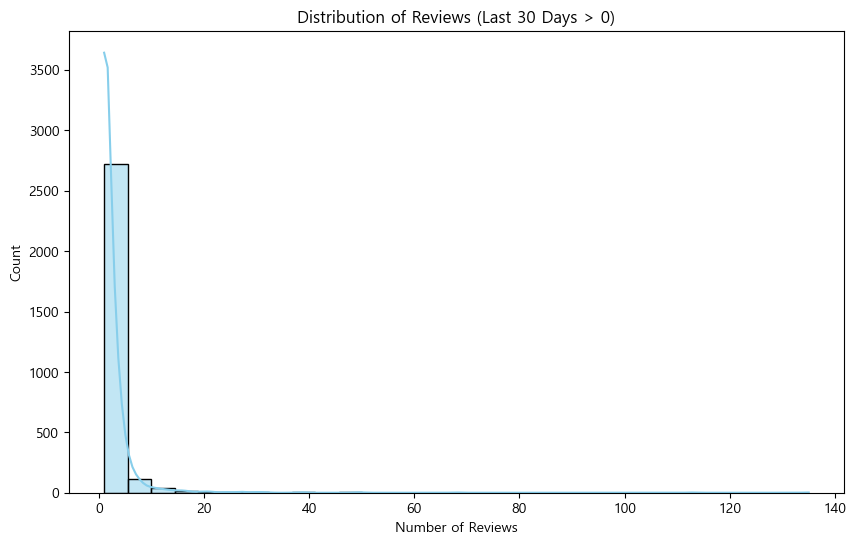

In [ ]:
target_l30d = df.loc[df["number_of_reviews_l30d"] > 0, "number_of_reviews_l30d"]

plt.figure(figsize=(10, 6))
sns.histplot(target_l30d, kde=True, color="skyblue", bins=30)
plt.title("Distribution of Reviews (Last 30 Days > 0)")
plt.xlabel("Number of Reviews")
plt.ylabel("Count")
plt.show()

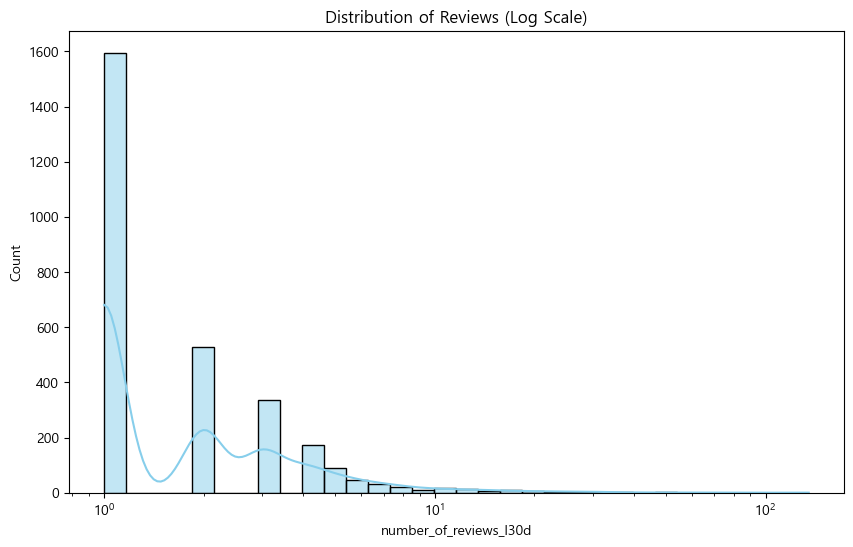

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(target_l30d, kde=True, color="skyblue", log_scale=True)
plt.title("Distribution of Reviews (Log Scale)")
plt.show()

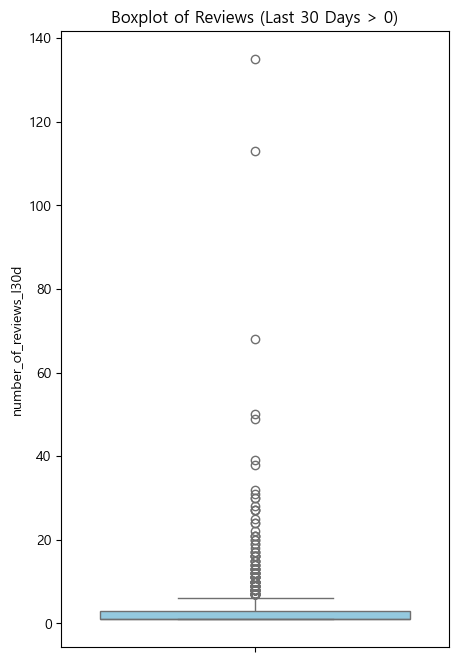

In [ ]:
plt.figure(figsize=(5, 8))
sns.boxplot(target_l30d, color="skyblue")
plt.title("Boxplot of Reviews (Last 30 Days > 0)")
plt.show()

In [ ]:
# amenities는 "[Wifi, Kitchen, ...]" 형태
import ast
from collections import Counter

amenities_list = df["amenities"].dropna().apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else []).copy()

all_amenities = [item.strip() for sublist in amenities_list for item in sublist]
amenities_counts = Counter(all_amenities)

# 상위 20개
print(amenities_counts.most_common(5537))

[('Smoke alarm', 21096), ('Wifi', 20577), ('Carbon monoxide alarm', 19386), ('Kitchen', 19122), ('Hot water', 17333), ('Essentials', 16548), ('Hangers', 16524), ('Hair dryer', 15354), ('Iron', 15268), ('Air conditioning', 14922), ('Bed linens', 14873), ('Refrigerator', 14557), ('Dishes and silverware', 14344), ('Cooking basics', 14064), ('Microwave', 13865), ('Heating', 13707), ('Dedicated workspace', 13073), ('TV', 12659), ('Shampoo', 11912), ('Self check-in', 11532), ('Fire extinguisher', 11115), ('Long term stays allowed', 10738), ('First aid kit', 9538), ('Coffee maker', 9444), ('Oven', 9374), ('Free street parking', 9331), ('Extra pillows and blankets', 8932), ('Bathtub', 8745), ('Cleaning products', 8537), ('Freezer', 8352), ('Hot water kettle', 7768), ('Dining table', 7521), ('Stove', 7249), ('Wine glasses', 7032), ('Private entrance', 6773), ('Toaster', 6751), ('Exterior security cameras on property', 6669), ('Dishwasher', 6614), ('Laundromat nearby', 6611), ('Shower gel', 6567